<a href="https://colab.research.google.com/github/OtsoHelminen/OtsoHelminen.github.io/blob/main/SigRegress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install iisignature
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import iisignature


In [ ]:
#OU-esimerkki
SEED = 410391249323

J = 1000
N = 1000
M = [1,2,5]
beta1 = 0.05
beta2 = 0.05

ApproxOUPaths = {}

# Simuloidaan N kappaletta Brownin liikkeen polkuja
print(f"Luodaan {N} simulaatiota Brownin liikkeen poluista")
print(f"Status: Työn alla...")
t = np.linspace(0, 1, J)
dt = t[1] - t[0]
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, (N, J-1))

Bpaths = np.zeros((N, J))
Bpaths[:, 1:] = np.cumsum(np.sqrt(dt) * Z, axis=1)
print(f"Status: Valmis!")

# Generoidaan OU-prosessit Brownin liikkeistä
print(f"Generoidaan OU-prosessit Brownin liikkeistä")
theta, mu, sigma = 1.0, 0.25, 1.25
OUpaths = np.zeros((N, J))
for j in range(J-1):
  OUpaths[:, j+1] = OUpaths[:, j] + theta * (mu - OUpaths[:, j]) * dt + sigma * np.sqrt(dt) * Z[:, j]

# Generoidaan approksimoitava OU-prosessi
print(f"Generoidaan approksimoitava kohdeprosessi")
TargetZ = rng.normal(0, 1, J-1)
TargetOUpath = np.zeros(J)
for j in range(J-1):
  TargetOUpath[j+1] = TargetOUpath[j] + theta * (mu - TargetOUpath[j]) * dt + sigma * np.sqrt(dt) * TargetZ[j]

# Minimoitava regressiolauseke ja sen gradientti
def objective_and_grad(f, signatures, targetpaths, beta1, beta2):
  predictions = np.tensordot(signatures, f, axes=([2], [0]))
  mse = np.mean((targetpaths - predictions) ** 2)
  penalty = beta1 * np.sum(np.abs(f)) + beta2 * np.sum(f**2)
  obj_value = mse + penalty

  # Lasketaan gradientti
  residuals = predictions - targetpaths
  grad_mse = 2 * np.mean(signatures * residuals[:, :, np.newaxis], axis=(0, 1))
  grad_l1 = beta1 * np.sign(f)
  grad_l2 = 2 * beta2 * f
  grad_f = grad_mse + grad_l1 + grad_l2

  return obj_value, grad_f

# Lasketaan regressioparametrit eri katkaisuasteille
for m in M:
  # Lasketaan Brownin liikkeiden signatuurit jokaiselle aika-askeleelle
  print(f"Aloitetaan signatuurien laskeminen katkaisuasteella {m}")
  sig_size = iisignature.siglength(2, m) + 1

  Bsignatures = np.zeros((N, J, sig_size))
  Bsignatures[:, :, 0] = 1.0

  for n in range(N):
    stream = np.column_stack((t, Bpaths[n]))
    Bsignatures[n, 1:, 1:] = iisignature.sig(stream, m, 2)

  # Etsitään argmin f
  print(f"Etsitään regressioparametrit")
  x0 = np.random.uniform(-1,1,sig_size)
  OptimResult = minimize(objective_and_grad, x0=x0, args=(Bsignatures, OUpaths, beta1, beta2), method="L-BFGS-B", jac=True)
  fstar = OptimResult.x
  print(f"Regressioparametrit löydetty!")

  TargetStream = np.column_stack((t, TargetOUpath))
  Targetsignatures = np.zeros((J, sig_size))
  Targetsignatures[:, 0] = 1.0
  Targetsignatures[1:, 1:] = iisignature.sig(TargetStream, m, 2)

  # Lasketaan regressiopolku matriisi-vektori-tulolla
  print(f"Lasketaan regressiopolku")
  ApproxPath = Targetsignatures @ fstar
  ApproxOUPaths[m] = ApproxPath
  print(f"Approksimointiprosessi valmis!")

Luodaan 1000 simulaatiota Brownin liikkeen poluista
Status: Työn alla...
Status: Valmis!
Generoidaan OU-prosessit Brownin liikkeistä
Generoidaan approksimoitava kohdeprosessi
Aloitetaan signatuurien laskeminen katkaisuasteella 1
Etsitään regressioparametrit
Regressioparametrit löydetty!
Lasketaan regressiopolku
Approksimointiprosessi valmis!
Aloitetaan signatuurien laskeminen katkaisuasteella 2
Etsitään regressioparametrit
Regressioparametrit löydetty!
Lasketaan regressiopolku
Approksimointiprosessi valmis!
Aloitetaan signatuurien laskeminen katkaisuasteella 5
Etsitään regressioparametrit
Regressioparametrit löydetty!
Lasketaan regressiopolku
Approksimointiprosessi valmis!


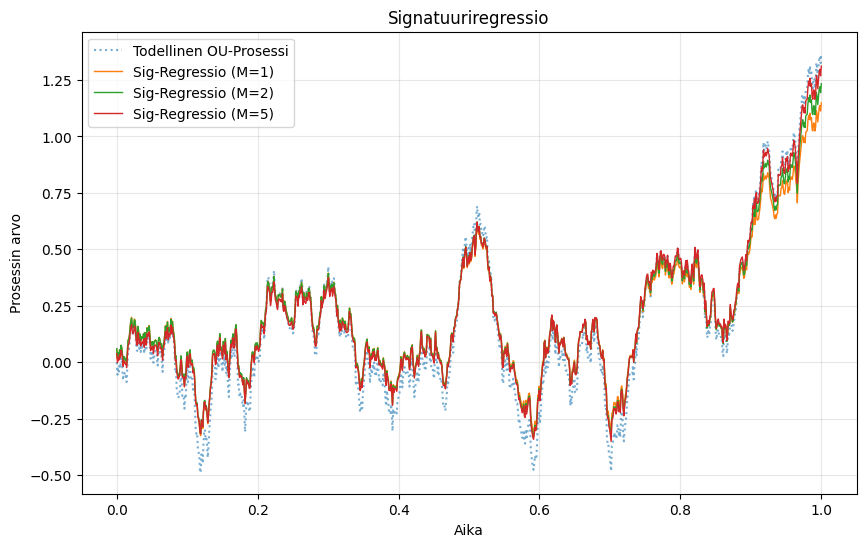

In [ ]:
# Luodaan kuvaaja
plt.figure(figsize=(10, 6))
plt.plot(t, TargetOUpath, linestyle="dotted", label="Todellinen OU-Prosessi", alpha=0.6)
for m in M:
  plt.plot(t, ApproxOUPaths[m], label=f"Sig-Regressio (M={m})", linewidth=1)
plt.title(f"Signatuuriregressio")
plt.xlabel("Aika")
plt.ylabel("Prosessin arvo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print("--- Mean Squared Error (MSE) for each M ---")
for m in M:
  mse = np.mean((TargetOUpath - ApproxOUPaths[m]) ** 2)
  print(f"M={m}: MSE = {mse:.5e}")

--- Mean Squared Error (MSE) for each M ---
M=1: MSE = 6.34340e-03
M=2: MSE = 4.56466e-03
M=5: MSE = 3.32237e-03


In [ ]:
#GBM-esimerkki
SEED = 8598433798

J = 1000
N = 1000
M = [1,2,5]
beta1 = 0.05
beta2 = 0.05

ApproxGBMPaths = {}

rng = np.random.default_rng(SEED)

# Simuloidaan N kappaletta Brownin liikkeen polkuja
print(f"Luodaan {N} simulaatiota Brownin liikkeen poluista")
print(f"Status: Työn alla...")
t = np.linspace(0, 1, J)
dt = t[1] - t[0]
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, (N, J-1))

Bpaths = np.zeros((N, J))
Bpaths[:, 1:] = np.cumsum(np.sqrt(dt) * Z, axis=1)
print(f"Status: Valmis!")

# Generoidaan GBM-prosessit Brownin liikkeistä
print(f"Generoidaan GBM-prosessit Brownin liikkeistä")
mu, sigma = 0.15, 0.25
GBMpaths = np.zeros((N, J))
GBMpaths[:, 0] = 1.0
for j in range(J-1):
  GBMpaths[:, j+1] = GBMpaths[:, j] * (1 + mu * dt + sigma * np.sqrt(dt) * Z[:, j])

# Generoidaan approksimoitava GBM-prosessi
print(f"Generoidaan approksimoitava kohdeprosessi")
TargetZ = rng.normal(0, 1, J-1)
TargetGBMpath = np.zeros(J)
TargetGBMpath[0] = 1.0
for j in range(J-1):
  TargetGBMpath[j+1] = TargetGBMpath[j] * (1 + mu * dt + sigma * np.sqrt(dt) * TargetZ[j])

# Minimoitava regressiolauseke ja sen gradientti
def regressfunc_w_grad(f, signatures, targetpaths, beta1, beta2):
  predictions = np.tensordot(signatures, f, axes=([2], [0]))
  mse = np.mean((targetpaths - predictions) ** 2)
  penalty = beta1 * np.sum(np.abs(f)) + beta2 * np.sum(f**2)
  obj_value = mse + penalty

  # Lasketaan gradientti
  residuals = predictions - targetpaths
  grad_mse = 2 * np.mean(signatures * residuals[:, :, np.newaxis], axis=(0, 1))
  grad_l1 = beta1 * np.sign(f)
  grad_l2 = 2 * beta2 * f
  grad_f = grad_mse + grad_l1 + grad_l2

  return obj_value, grad_f

# Lasketaan regressioparametrit eri katkaisuasteille
for m in M:
  # Lasketaan Brownin liikkeiden signatuurit jokaiselle aika-askeleelle
  print(f"Lasketaan signatuurit katkaisuasteella {m}")
  sig_size = iisignature.siglength(2, m) + 1

  Bsignatures = np.zeros((N, J, sig_size))
  Bsignatures[:, :, 0] = 1.0

  for n in range(N):
    stream = np.column_stack((t, Bpaths[n]))
    Bsignatures[n, 1:, 1:] = iisignature.sig(stream, m, 2)

  # Etsitään argmin f
  print(f"Etsitään regressioparametrit")
  x0 = np.random.uniform(-1,1,sig_size)
  OptimResult = minimize(regressfunc_w_grad, x0=x0, args=(Bsignatures, Bpaths, beta1, beta2), method="L-BFGS-B", jac=True)
  fstar = OptimResult.x
  print(f"Regressioparametrit löydetty!")

  TargetStream = np.column_stack((t, TargetGBMpath))
  Targetsignatures = np.zeros((J, sig_size))
  Targetsignatures[:, 0] = 1.0
  Targetsignatures[1:, 1:] = iisignature.sig(TargetStream, m, 2)

  # Lasketaan regressiopolku matriisi-vektori-tulolla
  print(f"Lasketaan regressiopolku")
  ApproxPath = Targetsignatures @ fstar
  ApproxPath[:] += 1
  ApproxGBMPaths[m] = ApproxPath
  print(f"Approksimointiprosessi valmis!")

Luodaan 1000 simulaatiota Brownin liikkeen poluista
Status: Työn alla...
Status: Valmis!
Generoidaan GBM-prosessit Brownin liikkeistä
Generoidaan approksimoitava kohdeprosessi
Lasketaan signatuurit katkaisuasteella 1
Etsitään regressioparametrit
Regressioparametrit löydetty!
Lasketaan regressiopolku
Approksimointiprosessi valmis!
Lasketaan signatuurit katkaisuasteella 2
Etsitään regressioparametrit
Regressioparametrit löydetty!
Lasketaan regressiopolku
Approksimointiprosessi valmis!
Lasketaan signatuurit katkaisuasteella 5
Etsitään regressioparametrit
Regressioparametrit löydetty!
Lasketaan regressiopolku
Approksimointiprosessi valmis!


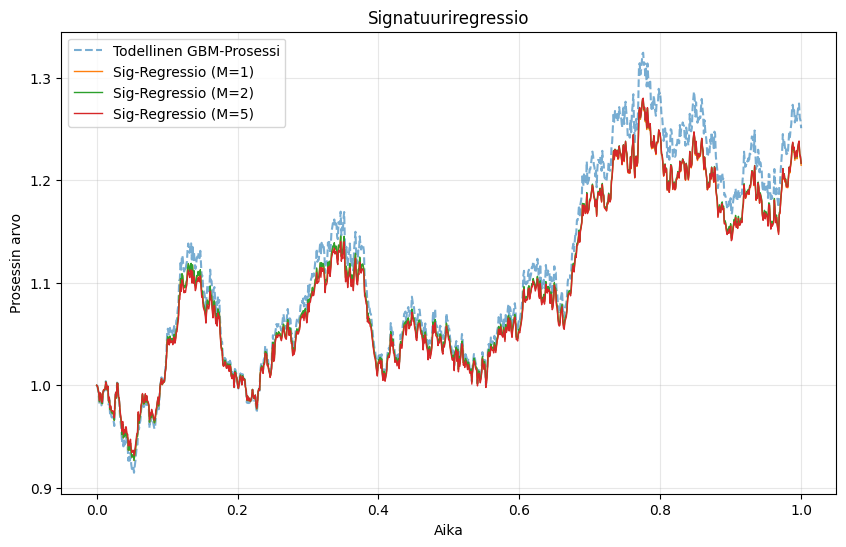

In [ ]:
# Luodaan kuvaaja
plt.figure(figsize=(10, 6))
plt.plot(t, TargetGBMpath, linestyle="dashed", label="Todellinen GBM-Prosessi", alpha=0.6)
for m in M:
  plt.plot(t, ApproxGBMPaths[m], label=f"Sig-Regressio (M={m})", linewidth=1)
plt.title(f"Signatuuriregressio")
plt.xlabel("Aika")
plt.ylabel("Prosessin arvo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print("--- Mean Squared Error (MSE) for each M ---")
for m in M:
  mse = np.mean((TargetGBMpath - ApproxGBMPaths[m]) ** 2)
  print(f"M={m}: MSE = {mse:.5e}")

--- Mean Squared Error (MSE) for each M ---
M=1: MSE = 4.52552e-04
M=2: MSE = 4.13735e-04
M=5: MSE = 4.81755e-04


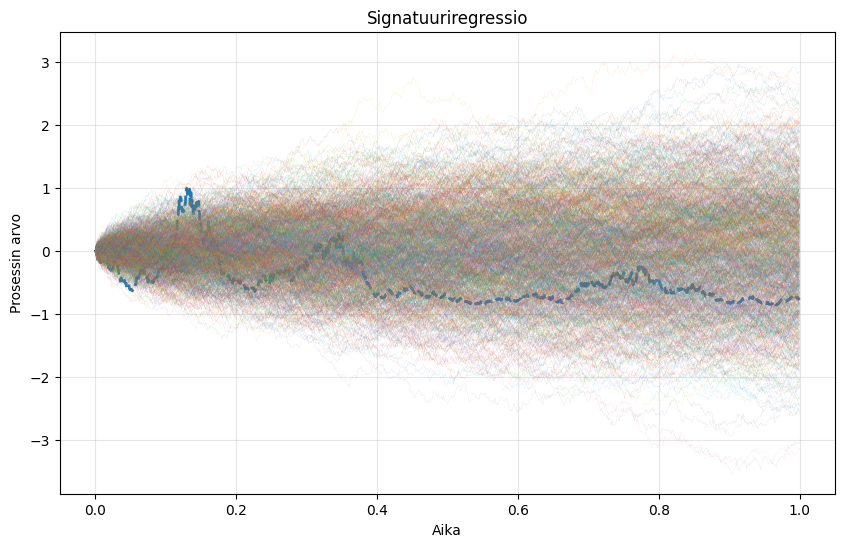

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, TargetGBMpath - 1, linestyle="dashed", label="Todellinen GBM-Prosessi", linewidth = 2)
for path in Bpaths:
  plt.plot(t, path, linewidth = 0.1, alpha = 0.5)
plt.title(f"Signatuuriregressio")
plt.xlabel("Aika")
plt.ylabel("Prosessin arvo")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
log_Bpaths = np.log(Bpaths)

/tmp/ipykernel_26665/3429711656.py:1: RuntimeWarning: invalid value encountered in log
  log_Bpaths = np.log(Bpaths)


In [ ]:
t = np.array([1,2,3,4])
process = np.array([0.1,0.05,0.12,0.45])
striim = np.column_stack((t,process))
print(iisignature.sig(striim,2,2))

[[ 1.000e+00 -5.000e-02  5.000e-01 -2.500e-02 -2.500e-02  1.250e-03]
 [ 2.000e+00  2.000e-02  2.000e+00  8.000e-02 -4.000e-02  2.000e-04]
 [ 3.000e+00  3.500e-01  4.500e+00  9.050e-01  1.450e-01  6.125e-02]]
